Assertion passed: item-kNN RMSE beats bias
Assertion passed: user-kNN RMSE beats bias
Assertion passed: best kNN NDCG beats content


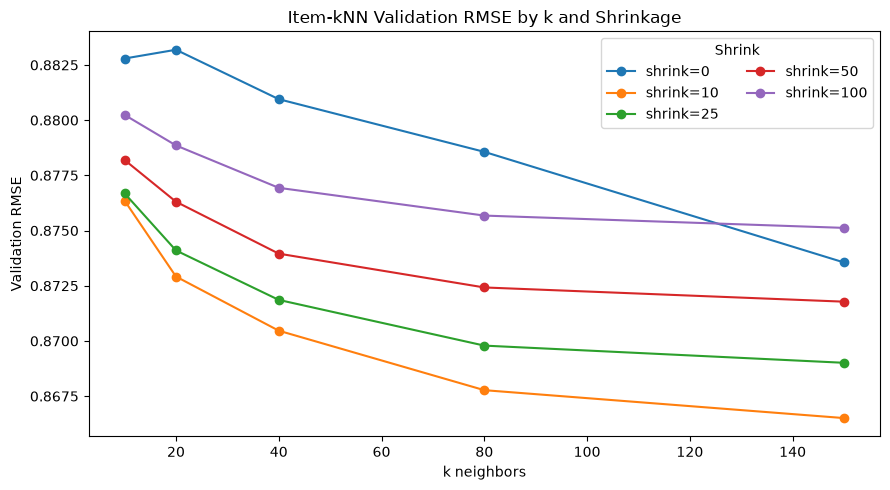

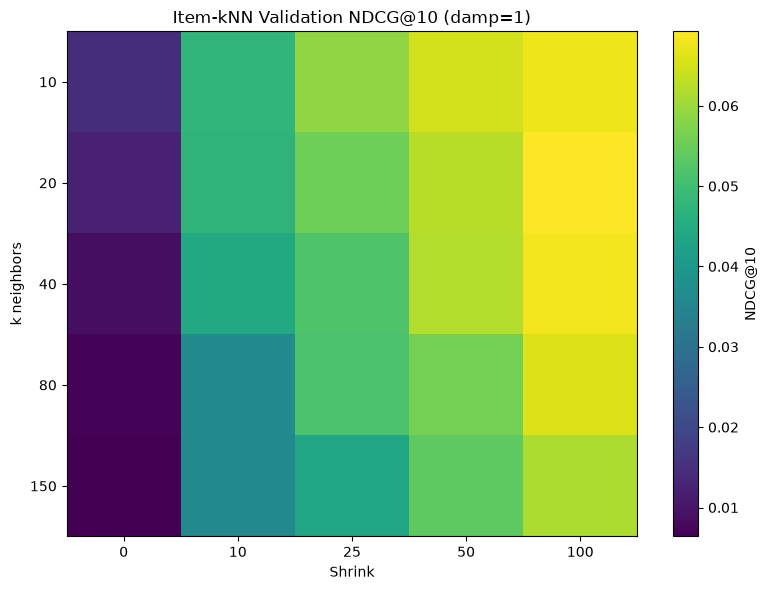

Best configurations (RMSE and NDCG selected independently):
{
  "item_knn": {
    "ndcg_best": {
      "coverage": 0.08396633134879901,
      "damp": 5.0,
      "k": 20,
      "ndcg@10": 0.07492632060920144,
      "novelty": 9.865665677687767,
      "recall@10": 0.08228977955937089,
      "shrink": 100
    },
    "rmse_best": {
      "damp": 0.5,
      "k": 150,
      "mae": 0.6587834285059664,
      "rmse": 0.863987156195024,
      "shrink": 10
    }
  },
  "user_knn": {
    "ndcg_best": {
      "coverage": 0.07893656333401766,
      "damp": 5.0,
      "k": 150,
      "ndcg@10": 0.059170674120910365,
      "novelty": 9.973193680557959,
      "recall@10": 0.06701455331826027,
      "shrink": 100
    },
    "rmse_best": {
      "damp": 0.1,
      "k": 150,
      "mae": 0.6639427527196617,
      "rmse": 0.8699780353415544,
      "shrink": 100
    }
  }
}
Residual vs raw-rating item similarity:
 similarity   rmse  ndcg@10
   residual 0.8851   0.0749
raw ratings 0.8805   0.0669
Implicit vs

metric,coverage,mae,map@10,ndcg@10,novelty,precision@10,recall@10,rmse,users_evaluated
model,,,,,,,,,
bias,0.0052,0.6823,0.0196,0.0371,9.1801,0.0222,0.0405,0.8876,554.0
content,0.0488,NaN,0.0383,0.0653,9.0832,0.0316,0.0765,NaN,554.0
item_knn,0.0840,0.6588,0.0404,0.0749,9.8657,0.0419,0.0823,0.8640,554.0
item_knn_implicit,0.0507,NaN,0.0507,0.0903,9.3758,0.0478,0.0964,NaN,554.0
popularity_bayes,0.0053,0.7601,0.0214,0.0404,9.0163,0.0245,0.0446,0.9829,554.0
popularity_count,0.0089,0.8187,0.0374,0.0638,8.4866,0.0327,0.0768,1.0415,554.0
random,0.4320,0.8187,0.0001,0.0004,19.8228,0.0005,0.0003,1.0415,554.0
user_knn,0.0789,0.6639,0.0302,0.0592,9.9732,0.0329,0.0670,0.8700,554.0
user_knn_implicit,0.0211,NaN,0.0476,0.0829,8.7522,0.0428,0.0986,NaN,554.0


In [5]:
import sys; sys.path.append("..")

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.sparse import csr_matrix

from src.config import ARTIFACTS, DATA_PROC, REL_THRESHOLD, REPORTS, TOP_K
from src.evaluate import evaluate_ranking, evaluate_rating
from src.metrics import rmse
from src.models.baselines import BiasModel
from src.models.knn import ItemKNN, UserKNN, residual_matrix, topk_similarity

train = pd.read_parquet(DATA_PROC / "train.parquet")
val = pd.read_parquet(DATA_PROC / "val.parquet")
movies = pd.read_parquet(DATA_PROC / "movies.parquet")
n_users = 610
n_items = len(movies)
assert np.array_equal(movies["i"].to_numpy(), np.arange(n_items))

bias = BiasModel().fit(train, n_users, n_items)
ks = [10, 20, 40, 80, 150]
shrinks = [0, 10, 25, 50, 100]
damps = [0.1, 0.5, 1, 2, 5]
model_specs = {
    "item_knn": (ItemKNN, ks, shrinks),
    "user_knn": (UserKNN, [10, 20, 40, 80, 150], shrinks),
}
search_records = []


def evaluate_trial(model_name, model_class, k, shrink, damp, mode="residual", stage="grid", similarity="residual"):
    model = model_class(bias, k=k, shrink=shrink, damp=damp, mode=mode)
    model.fit(train, n_users, n_items)
    rating_metrics = evaluate_rating(model, val) if mode == "residual" else {}
    ranking_metrics = evaluate_ranking(
        model, train, val, n_items=n_items, k=TOP_K, thr=REL_THRESHOLD
    )
    params = {
        "k": int(k), "shrink": int(shrink), "damp": float(damp),
        "mode": mode, "similarity": similarity,
    }
    row = {
        "model": model_name,
        "stage": stage,
        **params,
        "rmse": rating_metrics.get("rmse", np.nan),
        "mae": rating_metrics.get("mae", np.nan),
        "precision@10": ranking_metrics["precision@10"],
        "recall@10": ranking_metrics["recall@10"],
        "ndcg@10": ranking_metrics["ndcg@10"],
        "map@10": ranking_metrics["map@10"],
        "coverage": ranking_metrics["coverage"],
        "novelty": ranking_metrics["novelty"],
        "users_evaluated": ranking_metrics["users_evaluated"],
        "params": json.dumps(params, sort_keys=True, default=lambda value: value.item() if hasattr(value, 'item') else value),
    }
    search_records.append(row)
    return row


# Stage 1: k x shrink with fixed damp=1.0.
for model_name, (model_class, model_ks, model_shrinks) in model_specs.items():
    for k in model_ks:
        for shrink in model_shrinks:
            evaluate_trial(model_name, model_class, k, shrink, 1.0, stage="grid")

# Stage 2: tune damp around both the RMSE-best and NDCG-best k/shrink pairs.
for model_name, (model_class, _, _) in model_specs.items():
    grid_rows = [
        row for row in search_records
        if row["model"] == model_name and row["stage"] == "grid"
    ]
    rmse_pair = min(grid_rows, key=lambda row: row["rmse"])
    ndcg_pair = max(grid_rows, key=lambda row: row["ndcg@10"])
    for objective, pair in (("rmse", rmse_pair), ("ndcg", ndcg_pair)):
        for damp in damps:
            if damp == 1.0:
                continue
            evaluate_trial(
                model_name, model_class, pair["k"], pair["shrink"], damp,
                stage=f"damp_{objective}",
            )

# Compare residual-based and raw-rating similarity for the best item ranking config.
item_rows = [
    row for row in search_records
    if row["model"] == "item_knn" and row["mode"] == "residual"
    and row["similarity"] == "residual"
]
item_best_ndcg_for_raw = max(item_rows, key=lambda row: row["ndcg@10"])
raw_item_model = ItemKNN(
    bias, k=item_best_ndcg_for_raw["k"], shrink=item_best_ndcg_for_raw["shrink"],
    damp=item_best_ndcg_for_raw["damp"], mode="residual",
).fit(train, n_users, n_items)
raw_items = train["i"].to_numpy(dtype=np.int32)
raw_users = train["u"].to_numpy(dtype=np.int32)
raw_values = train["rating"].to_numpy(dtype=np.float32)
raw_matrix = csr_matrix(
    (raw_values, (raw_users, raw_items)), shape=(n_users, n_items), dtype=np.float32
)
raw_item_model.W = topk_similarity(
    raw_matrix.T.tocsr(), raw_item_model.B.T.tocsr(),
    item_best_ndcg_for_raw["k"], item_best_ndcg_for_raw["shrink"],
)
raw_item_model.Wabs = abs(raw_item_model.W).tocsr()
raw_item_model._predict_cache = {}
raw_rating_metrics = evaluate_rating(raw_item_model, val)
raw_ranking_metrics = evaluate_ranking(
    raw_item_model, train, val, n_items=n_items, k=TOP_K, thr=REL_THRESHOLD
)
raw_params = {
    "k": item_best_ndcg_for_raw["k"], "shrink": item_best_ndcg_for_raw["shrink"],
    "damp": item_best_ndcg_for_raw["damp"], "mode": "residual",
    "similarity": "raw_ratings",
}
search_records.append({
    "model": "item_knn", "stage": "raw_similarity", **raw_params,
    "rmse": raw_rating_metrics["rmse"], "mae": raw_rating_metrics["mae"],
    "precision@10": raw_ranking_metrics["precision@10"],
    "recall@10": raw_ranking_metrics["recall@10"],
    "ndcg@10": raw_ranking_metrics["ndcg@10"],
    "map@10": raw_ranking_metrics["map@10"],
    "coverage": raw_ranking_metrics["coverage"],
    "novelty": raw_ranking_metrics["novelty"],
    "users_evaluated": raw_ranking_metrics["users_evaluated"],
    "params": json.dumps(raw_params, sort_keys=True, default=lambda value: value.item() if hasattr(value, 'item') else value),
})

# Compare implicit and residual ranking for each model's best residual NDCG config.
implicit_metrics = {}
for model_name, (model_class, _, _) in model_specs.items():
    candidates = [
        row for row in search_records
        if row["model"] == model_name and row["mode"] == "residual"
        and row["similarity"] == "residual"
    ]
    best_ndcg = max(candidates, key=lambda row: row["ndcg@10"])
    implicit = model_class(
        bias, k=best_ndcg["k"], shrink=best_ndcg["shrink"],
        damp=best_ndcg["damp"], mode="implicit",
    ).fit(train, n_users, n_items)
    scores = evaluate_ranking(
        implicit, train, val, n_items=n_items, k=TOP_K, thr=REL_THRESHOLD
    )
    implicit_metrics[model_name] = scores
    params = {
        "k": best_ndcg["k"], "shrink": best_ndcg["shrink"],
        "damp": best_ndcg["damp"], "mode": "implicit",
    }
    search_records.append({
        "model": model_name, "stage": "implicit_comparison", **params,
        "rmse": np.nan, "mae": np.nan,
        "precision@10": scores["precision@10"], "recall@10": scores["recall@10"],
        "ndcg@10": scores["ndcg@10"], "map@10": scores["map@10"],
        "coverage": scores["coverage"], "novelty": scores["novelty"],
        "users_evaluated": scores["users_evaluated"],
        "params": json.dumps(params, sort_keys=True, default=lambda value: value.item() if hasattr(value, 'item') else value),
    })

search_results = pd.DataFrame(search_records)
REPORTS.mkdir(parents=True, exist_ok=True)
search_results.to_csv(REPORTS / "knn_search.csv", index=False)

selected_configs = {}
selected_rows = {}
for model_name in model_specs:
    candidates = search_results.loc[
        (search_results["model"] == model_name)
        & (search_results["mode"] == "residual")
        & (search_results["similarity"] == "residual")
    ]
    best_rmse = candidates.loc[candidates["rmse"].idxmin()]
    best_ndcg = candidates.loc[candidates["ndcg@10"].idxmax()]
    selected_rows[model_name] = {"rmse": best_rmse, "ndcg": best_ndcg}
    selected_configs[model_name] = {
        "rmse_best": {key: best_rmse[key].item() if hasattr(best_rmse[key], "item") else best_rmse[key]
                      for key in ("k", "shrink", "damp", "rmse", "mae")},
        "ndcg_best": {key: best_ndcg[key].item() if hasattr(best_ndcg[key], "item") else best_ndcg[key]
                      for key in ("k", "shrink", "damp", "ndcg@10", "recall@10", "coverage", "novelty")},
    }

ARTIFACTS.mkdir(parents=True, exist_ok=True)
with (ARTIFACTS / "knn_config.json").open("w", encoding="utf-8") as config_file:
    json.dump(selected_configs, config_file, indent=2, sort_keys=True, default=lambda value: value.item() if hasattr(value, 'item') else value)

# Append RMSE/MAE from the RMSE-best settings and ranking metrics from NDCG-best settings.
results_path = REPORTS / "results_val.csv"
results_val = pd.read_csv(results_path)
knn_names = {"item_knn", "user_knn", "item_knn_implicit", "user_knn_implicit"}
results_val = results_val.loc[~results_val["model"].isin(knn_names)]
metric_rows = []
rank_metrics = ["precision@10", "recall@10", "ndcg@10", "map@10", "coverage", "novelty", "users_evaluated"]
for model_name, rows in selected_rows.items():
    for metric in ("rmse", "mae"):
        metric_rows.append({
            "model": model_name, "split": "val", "metric": metric,
            "value": rows["rmse"][metric],
            "params": json.dumps({"k": rows["rmse"]["k"], "shrink": rows["rmse"]["shrink"],
                                  "damp": rows["rmse"]["damp"], "mode": "residual",
                                  "selected_for": "rmse"}, sort_keys=True, default=lambda value: value.item() if hasattr(value, 'item') else value),
        })
    for metric in rank_metrics:
        source = rows["ndcg"]
        metric_rows.append({
            "model": model_name, "split": "val", "metric": metric,
            "value": source[metric],
            "params": json.dumps({"k": source["k"], "shrink": source["shrink"],
                                  "damp": source["damp"], "mode": "residual",
                                  "selected_for": "ndcg@10"}, sort_keys=True, default=lambda value: value.item() if hasattr(value, 'item') else value),
        })
    implicit_scores = implicit_metrics[model_name]
    implicit_best = rows["ndcg"]
    implicit_params = json.dumps({
        "k": implicit_best["k"], "shrink": implicit_best["shrink"],
        "damp": implicit_best["damp"], "mode": "implicit",
    }, sort_keys=True, default=lambda value: value.item() if hasattr(value, 'item') else value)
    for metric in rank_metrics:
        metric_rows.append({
            "model": f"{model_name}_implicit", "split": "val", "metric": metric,
            "value": implicit_scores[metric], "params": implicit_params,
        })
results_val = pd.concat([results_val, pd.DataFrame(metric_rows)], ignore_index=True)
results_val = results_val[["model", "split", "metric", "value", "params"]]
results_val.to_csv(results_path, index=False)

# Bias-removal comparison uses the same item-neighborhood hyperparameters.
baseline_rmse = results_val.loc[
    (results_val["model"] == "bias") & (results_val["metric"] == "rmse"), "value"
].iloc[-1]
content_ndcg = results_val.loc[
    (results_val["model"] == "content") & (results_val["metric"] == "ndcg@10"), "value"
].iloc[-1]
best_item_rmse = float(selected_rows["item_knn"]["rmse"]["rmse"])
best_user_rmse = float(selected_rows["user_knn"]["rmse"]["rmse"])
best_knn_ndcg = max(float(rows["ndcg"]["ndcg@10"]) for rows in selected_rows.values())
assertion_notes = []

def check_assertion(label, condition, detail):
    try:
        assert condition, detail
        print("Assertion passed:", label)
    except AssertionError as error:
        message = f"{label}: {error}"
        assertion_notes.append(message)
        print("ASSERTION FAILED:", message)

check_assertion(
    "item-kNN RMSE beats bias",
    best_item_rmse < baseline_rmse,
    f"item-kNN RMSE={best_item_rmse:.4f}; bias RMSE={baseline_rmse:.4f}",
)
check_assertion(
    "user-kNN RMSE beats bias",
    best_user_rmse < baseline_rmse,
    f"user-kNN RMSE={best_user_rmse:.4f}; bias RMSE={baseline_rmse:.4f}",
)
check_assertion(
    "best kNN NDCG beats content",
    best_knn_ndcg > content_ndcg,
    f"best kNN NDCG@10={best_knn_ndcg:.4f}; content NDCG@10={content_ndcg:.4f}",
)
if assertion_notes:
    display(Markdown("### Assertion notes\n" + "\n".join(f"- {note}" for note in assertion_notes)))

# Item-kNN validation plots use only the initial k x shrink grid (damp=1).
item_grid = search_results.loc[
    (search_results["model"] == "item_knn")
    & (search_results["stage"] == "grid")
    & (search_results["mode"] == "residual")
]
rmse_pivot = item_grid.pivot(index="k", columns="shrink", values="rmse").sort_index()
ndcg_pivot = item_grid.pivot(index="k", columns="shrink", values="ndcg@10").sort_index()
plot_dir = REPORTS / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(9, 5))
for shrink in rmse_pivot.columns:
    ax.plot(rmse_pivot.index, rmse_pivot[shrink], marker="o", label=f"shrink={shrink}")
ax.set(title="Item-kNN Validation RMSE by k and Shrinkage", xlabel="k neighbors", ylabel="Validation RMSE")
ax.legend(title="Shrink", ncol=2)
fig.tight_layout()
fig.savefig(plot_dir / "knn_item_rmse_by_k.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(ndcg_pivot.to_numpy(), aspect="auto", cmap="viridis")
ax.set(title="Item-kNN Validation NDCG@10 (damp=1)", xlabel="Shrink", ylabel="k neighbors")
ax.set_xticks(np.arange(len(ndcg_pivot.columns)), labels=ndcg_pivot.columns)
ax.set_yticks(np.arange(len(ndcg_pivot.index)), labels=ndcg_pivot.index)
fig.colorbar(image, ax=ax, label="NDCG@10")
fig.tight_layout()
fig.savefig(plot_dir / "knn_item_ndcg_heatmap.png", dpi=160)
plt.show()

print("Best configurations (RMSE and NDCG selected independently):")
print(json.dumps(selected_configs, indent=2, sort_keys=True, default=lambda value: value.item() if hasattr(value, 'item') else value))
print("Residual vs raw-rating item similarity:")
print(pd.DataFrame([
    {"similarity": "residual", "rmse": selected_rows["item_knn"]["ndcg"]["rmse"],
     "ndcg@10": selected_rows["item_knn"]["ndcg"]["ndcg@10"]},
    {"similarity": "raw ratings", "rmse": raw_rating_metrics["rmse"],
     "ndcg@10": raw_ranking_metrics["ndcg@10"]},
]).round(4).to_string(index=False))
print("Implicit vs residual ranking at each model's NDCG-best configuration:")
print(pd.DataFrame([
    {"model": name, "mode": mode, "ndcg@10": metrics["ndcg@10"],
     "recall@10": metrics["recall@10"], "coverage": metrics["coverage"],
     "novelty": metrics["novelty"]}
    for name, mode, metrics in [
        ("item_knn", "residual", selected_rows["item_knn"]["ndcg"]),
        ("item_knn", "implicit", implicit_metrics["item_knn"]),
        ("user_knn", "residual", selected_rows["user_knn"]["ndcg"]),
        ("user_knn", "implicit", implicit_metrics["user_knn"]),
    ]
]).round(4).to_string(index=False))
print(f"Saved {len(search_results)} trial rows to {REPORTS / 'knn_search.csv'}.")
print(f"Item-kNN line plot and heatmap saved under {plot_dir}.")

results_val = pd.read_csv(results_path)
final_table = results_val.pivot_table(index="model", columns="metric", values="value", aggfunc="first")
display(final_table.round(4))

### Findings
The item neighborhood performs better on both validation RMSE (0.8640 vs. 0.8700) and NDCG@10 (0.0749 vs. 0.0592) than the user neighborhood. There are 610 users but 9,742 items, so the user-similarity matrix is much smaller; nevertheless, item-kNN gives the stronger accuracy here. With the same item-kNN settings, residual similarity improves NDCG@10 over raw-rating similarity (0.0749 vs. 0.0669), while raw ratings give slightly lower RMSE (0.8805 vs. 0.8851).